In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dice Scores -> CSF: 0.2875, GM: 0.0000, WM: 0.0000


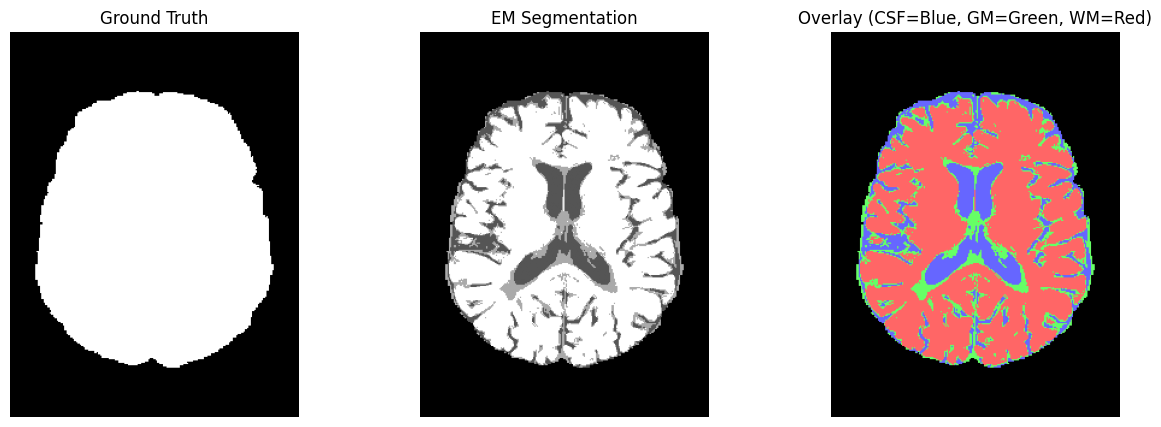

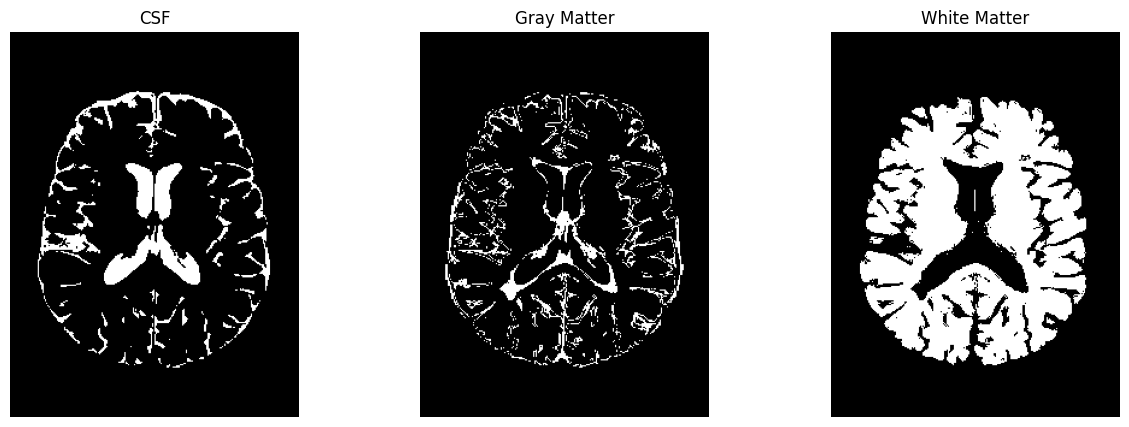

In [ ]:
!pip install SimpleITK matplotlib

import SimpleITK as sitk
import numpy as np
from sklearn.cluster import KMeans
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
import time


def e_step(multimodal_data, mu, covariances, alphas, k, epsilon=1e-6):
    n_samples = multimodal_data.shape[0]
    responsibilities = np.zeros((n_samples, k))
    for i in range(k):
        responsibilities[:, i] = alphas[i] * multivariate_normal.pdf(multimodal_data, mean=mu[i], cov=covariances[i])
    responsibilities_sum = responsibilities.sum(axis=1, keepdims=True)
    responsibilities_sum[responsibilities_sum == 0] = epsilon
    responsibilities /= responsibilities_sum
    return responsibilities

def m_step(multimodal_data, responsibilities, k):
    n_samples, n_features = multimodal_data.shape
    mu = np.zeros((k, n_features))
    covariances = []
    alphas = np.zeros(k)
    for i in range(k):
        responsibility_sum = responsibilities[:, i].sum()
        mu[i] = (responsibilities[:, i][:, np.newaxis] * multimodal_data).sum(axis=0) / responsibility_sum
        diff = multimodal_data - mu[i]
        covariance = np.dot((responsibilities[:, i][:, np.newaxis] * diff).T, diff) / responsibility_sum
        covariances.append(covariance + 1e-6 * np.eye(n_features))  # regularization
        alphas[i] = responsibility_sum / n_samples
    return mu, covariances, alphas

def compute_log_likelihood(multimodal_data, mu, covariances, alphas, k):
    log_likelihood = 0
    for i in range(k):
        log_likelihood += alphas[i] * multivariate_normal.pdf(multimodal_data, mean=mu[i], cov=covariances[i])
    log_likelihood = np.clip(log_likelihood, 1e-10, None)
    return np.log(log_likelihood).sum()

def EM_algorithm(multimodal_data, mu, covariances, alphas, k, max_iterations=100, tol=1e-4):
    log_likelihood_old = -np.inf
    for iteration in range(max_iterations):
        responsibilities = e_step(multimodal_data, mu, covariances, alphas, k)
        mu, covariances, alphas = m_step(multimodal_data, responsibilities, k)
        log_likelihood_new = compute_log_likelihood(multimodal_data, mu, covariances, alphas, k)
        if np.abs(log_likelihood_new - log_likelihood_old) < tol:
            print(f"Converged after {iteration} iterations.")
            break
        log_likelihood_old = log_likelihood_new
    return mu, covariances, alphas

def relabel_clusters_based_on_intensity(mu):
    sorted_indices = np.argsort(mu[:, 0])  # use T1 intensity
    cluster_map = {sorted_indices[0]: 1, sorted_indices[1]: 2, sorted_indices[2]: 3}
    return cluster_map

def assign_voxel_labels(multimodal_data, mu, covariances, alphas, k):
    responsibilities = e_step(multimodal_data, mu, covariances, alphas, k)
    original_cluster_labels = np.argmax(responsibilities, axis=1)
    cluster_map = relabel_clusters_based_on_intensity(mu)
    assigned_labels = np.vectorize(cluster_map.get)(original_cluster_labels)
    return assigned_labels

def dice_coefficient(segmented, ground_truth, label):
    seg_bin = (segmented == label).astype(np.uint8)
    gt_bin = (ground_truth == label).astype(np.uint8)
    intersection = np.sum(seg_bin * gt_bin)
    return (2. * intersection) / (np.sum(seg_bin) + np.sum(gt_bin) + 1e-10)


def run_em_segmentation(T1_path, T2_path, FLAIR_path, GT_path, k=3):
    # Load images
    T1 = sitk.GetArrayFromImage(sitk.ReadImage(T1_path))
    T2 = sitk.GetArrayFromImage(sitk.ReadImage(T2_path))
    FLAIR = sitk.GetArrayFromImage(sitk.ReadImage(FLAIR_path))
    GT = sitk.GetArrayFromImage(sitk.ReadImage(GT_path))

    # Apply brain mask to remove background
    mask = (GT > 0)
    T1, T2, FLAIR = T1 * mask, T2 * mask, FLAIR * mask

    # Flatten data
    multimodal_data = np.stack([T1.flatten(), T2.flatten(), FLAIR.flatten()], axis=1)
    valid_voxels = np.any(multimodal_data != 0, axis=1)
    multimodal_data = multimodal_data[valid_voxels]

    # K-Means initialization
    kmeans = KMeans(n_clusters=k, random_state=42).fit(multimodal_data)
    mu = kmeans.cluster_centers_
    covariances = [np.cov(multimodal_data[kmeans.labels_ == i].T) for i in range(k)]
    alphas = np.bincount(kmeans.labels_) / len(kmeans.labels_)

    # EM Algorithm
    mu, covariances, alphas = EM_algorithm(multimodal_data, mu, covariances, alphas, k)

    # Assign voxel labels
    labels = assign_voxel_labels(multimodal_data, mu, covariances, alphas, k)

    # Reconstruct full 3D segmentation
    segmented = np.zeros(T1.shape, dtype=np.uint8)
    segmented_flat = segmented.flatten()
    segmented_flat[valid_voxels] = labels
    segmented = segmented_flat.reshape(T1.shape)

    # Dice scores
    dsc_csf = dice_coefficient(segmented, GT, 1)
    dsc_gm = dice_coefficient(segmented, GT, 2)
    dsc_wm = dice_coefficient(segmented, GT, 3)

    print(f"Dice Scores -> CSF: {dsc_csf:.4f}, GM: {dsc_gm:.4f}, WM: {dsc_wm:.4f}")
    return segmented, GT

def visualize_segmentation(segmented, GT, title="EM Segmentation"):
    slice_index = segmented.shape[0] // 2
    seg_slice = segmented[slice_index]
    gt_slice = GT[slice_index]

    # Overlay Segmentation (colors for each tissue)
    overlay = np.zeros((*seg_slice.shape, 3))
    overlay[seg_slice == 1] = [0, 0, 1]   # Blue - CSF
    overlay[seg_slice == 2] = [0, 1, 0]   # Green - GM
    overlay[seg_slice == 3] = [1, 0, 0]   # Red - WM

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(gt_slice, cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(seg_slice, cmap='gray', vmin=0, vmax=3)
    plt.title(title)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(gt_slice, cmap='gray')
    plt.imshow(overlay, alpha=0.6)
    plt.title('Overlay (CSF=Blue, GM=Green, WM=Red)')
    plt.axis('off')
    plt.show()

    # Separate tissue maps
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    tissues = ['CSF', 'Gray Matter', 'White Matter']
    for i, label in enumerate([1, 2, 3]):
        axes[i].imshow(seg_slice == label, cmap='gray')
        axes[i].set_title(f'{tissues[i]}')
        axes[i].axis('off')
    plt.show()


T1_path = "/content/drive/MyDrive/MIC UdG/MISA/Delivery P2/T1.nii"
T2_path = "/content/drive/MyDrive/MIC UdG/MISA/Delivery P2/T2.nii"
FLAIR_path = "/content/drive/MyDrive/MIC UdG/MISA/Delivery P2/FLAIR.nii"
GT_path = "/content/drive/MyDrive/MIC UdG/MISA/Delivery P2/brainMask.nii"

segmented, GT = run_em_segmentation(T1_path, T2_path, FLAIR_path, GT_path)
visualize_segmentation(segmented, GT)
